In [1]:
import subprocess
import tempfile
import os
import pandas as pd
from meeko import MoleculePreparation
from rdkit import Chem
from rdkit.Chem import AllChem

In [2]:
#Load Peptide CSV
csv_path = "../data/processed/sequences_reviewed.csv"  # Update if needed
peptides_df = pd.read_csv(csv_path)
peptides_df.head()

,Sequence,hemo,sol,nf,Net_Charge,Avg_Hydrophobicity,Isoelectric_Point,Solubility_Rules_Failed,Synthesis_Rules_Failed
0,VAGKVAIRKDVPEISGG,0.057322,0.863499,0.172162,0.999800,1.45,8.560644,2,0
1,WKTMSPKIVLEDKQALF,0.093982,0.719320,0.024920,0.997962,0.74,8.497658,1,1
2,WWCLECWCYIVKKKQNG,0.122263,0.905384,0.004087,1.862352,0.69,8.634267,2,2
3,KKWPKYCFCLVIEVLGS,0.117825,0.877333,0.007819,1.899992,3.68,8.821225,4,2
4,PIGICVYPSRNFVPSKD,0.081423,0.819775,0.098507,0.954786,1.43,8.603129,3,2


In [3]:
# Prepare receptor
receptor_pdb = "../data/external/vefg.pdb"   # input file
receptor_pdbqt = "../data/external/VEGF.pdbqt"
os.system(f"obabel {receptor_pdb} -O {receptor_pdbqt} -xp")

0

In [5]:
# Cell 4: Functions
def prepare_peptide_rdkit(sequence):
    """Try preparing peptide ligand with RDKit."""
    mol = Chem.MolFromSequence(sequence)
    mol = Chem.AddHs(mol)
    params = AllChem.ETKDGv3()
    params.randomSeed = 0xf00d
    success = AllChem.EmbedMolecule(mol, params)
    if success != 0:
        raise ValueError("RDKit embedding failed")
    try:
        AllChem.MMFFOptimizeMolecule(mol)
    except:
        print(f"⚠ Skipping MMFF optimization for {sequence}")
    tmp_pdb = tempfile.NamedTemporaryFile(delete=False, suffix=".pdb").name
    Chem.MolToPDBFile(mol, tmp_pdb)
    return tmp_pdb

def prepare_peptide_openbabel(sequence):
    """Prepare peptide ligand with OpenBabel."""
    tmp_pdb = tempfile.NamedTemporaryFile(delete=False, suffix=".pdb").name
    os.system(f'obabel -:"{sequence}" -opdb --gen3d -O {tmp_pdb}')
    return tmp_pdb

def prepare_peptide_pdbqt(sequence):
    """Robust peptide to pdbqt preparation."""
    try:
        pdb_file = prepare_peptide_rdkit(sequence)
    except Exception as e:
        print(f"❌ RDKit failed for {sequence}: {e} → Using OpenBabel")
        pdb_file = prepare_peptide_openbabel(sequence)

    preparator = MoleculePreparation()
    preparator.prepare(pdb_file)
    ligand_pdbqt = pdb_file.replace(".pdb", ".pdbqt")
    with open(ligand_pdbqt, "w") as f:
        f.write(preparator.write_pdbqt_string())
    return ligand_pdbqt

def run_qvina(receptor_pdbqt, ligand_pdbqt, out_pdbqt, center, size):
    """Run QuickVina2 docking."""
    cmd = [
        "qvina2",
        "--receptor", receptor_pdbqt,
        "--ligand", ligand_pdbqt,
        "--out", out_pdbqt,
        "--center_x", str(center[0]),
        "--center_y", str(center[1]),
        "--center_z", str(center[2]),
        "--size_x", str(size[0]),
        "--size_y", str(size[1]),
        "--size_z", str(size[2]),
        "--exhaustiveness", "8"
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    return result.stdout

def extract_best_score(qvina_log):
    """Extract best score from QuickVina log."""
    for line in qvina_log.splitlines():
        if line.strip().startswith("1 "):  # first pose
            try:
                return float(line.split()[1])
            except:
                return None
    return None

In [6]:
# Cell 5: Docking loop
center = [10.0, 10.0, 10.0]  # <-- Set to VEGF binding pocket center
size = [20.0, 20.0, 20.0]    # <-- Set to appropriate box size

results = []
for idx, row in peptides_df.iterrows():
    seq = row["Sequence"]
    print(f"🔄 Docking peptide {idx}: {seq}")
    try:
        ligand_pdbqt = prepare_peptide_pdbqt(seq)
        out_pdbqt = tempfile.NamedTemporaryFile(delete=False, suffix=".pdbqt").name
        log = run_qvina(receptor_pdbqt, ligand_pdbqt, out_pdbqt, center, size)
        score = extract_best_score(log)
        results.append({"Sequence": seq, "Binding_Affinity": score})
    except Exception as e:
        print(f"❌ Docking failed for {seq}: {e}")
        results.append({"Sequence": seq, "Binding_Affinity": None})

🔄 Docking peptide 0: VAGKVAIRKDVPEISGG
❌ RDKit failed for VAGKVAIRKDVPEISGG: RDKit embedding failed → Using OpenBabel
❌ Docking failed for VAGKVAIRKDVPEISGG: Molecule is not an instance of supported types: <class 'str'>
🔄 Docking peptide 1: WKTMSPKIVLEDKQALF
❌ RDKit failed for WKTMSPKIVLEDKQALF: RDKit embedding failed → Using OpenBabel
❌ Docking failed for WKTMSPKIVLEDKQALF: Molecule is not an instance of supported types: <class 'str'>
🔄 Docking peptide 2: WWCLECWCYIVKKKQNG
❌ RDKit failed for WWCLECWCYIVKKKQNG: RDKit embedding failed → Using OpenBabel
❌ Docking failed for WWCLECWCYIVKKKQNG: Molecule is not an instance of supported types: <class 'str'>
🔄 Docking peptide 3: KKWPKYCFCLVIEVLGS
❌ RDKit failed for KKWPKYCFCLVIEVLGS: RDKit embedding failed → Using OpenBabel
❌ Docking failed for KKWPKYCFCLVIEVLGS: Molecule is not an instance of supported types: <class 'str'>
🔄 Docking peptide 4: PIGICVYPSRNFVPSKD
❌ RDKit failed for PIGICVYPSRNFVPSKD: RDKit embedding failed → Using OpenBabel
❌ 

In [7]:
# Cell 6: Save and visualize
results_df = pd.DataFrame(results)
results_df.to_csv("../data/processed/docking_resultsqvina_docking_results.csv", index=False)
results_df

,Sequence,Binding_Affinity
0,VAGKVAIRKDVPEISGG,None
1,WKTMSPKIVLEDKQALF,None
2,WWCLECWCYIVKKKQNG,None
3,KKWPKYCFCLVIEVLGS,None
4,PIGICVYPSRNFVPSKD,None
5,GHNPPQIKYLAFANHLY,None


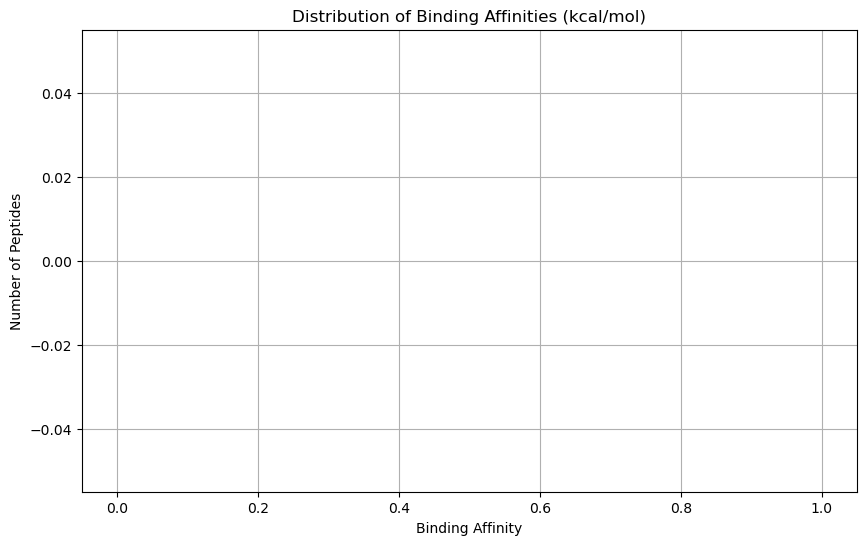

In [8]:
# Visualize Results
import matplotlib.pyplot as plt

filtered = results_df.dropna()
plt.figure(figsize=(10,6))
plt.hist(filtered['Binding_Affinity'], bins=20, color='skyblue')
plt.title("Distribution of Binding Affinities (kcal/mol)")
plt.xlabel("Binding Affinity")
plt.ylabel("Number of Peptides")
plt.grid(True)
plt.show()